# CISC7204 Assignment 01

**Submitted by:** Xiji Hang (MC646933).

## Module 02 · Lab 01 — Wrangling automobile data

**Collaborators:** Xiji Hang (MC646933) and Xiaoyu Guo (MC648131).  
**Contribution:** All laboratory work is completed jointly.

**Source:** Adapted from the supplied IBM / Skills Network teaching notebook; original author credits are retained below. The source template is preserved separately.

**Execution:** Local Anaconda / Jupyter; results in this working copy are generated by executing its code. Input: `auto.csv`, the unchanged dataset snapshot specified by this lab.

**Dataset source:** [auto.csv](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/auto.csv) (snapshot accessed 15 September 2026). Each row describes one automobile configuration with its specifications and listed price.

# Data Wrangling



    

## Objectives

After completing this lab you will be able to:

* Handle missing values
* Correct data formatting
* Standardize and normalize data

<h2>Table of Contents</h2>

<div class="alert alert-block alert-info" style="margin-top: 20px">
<ul>
    <li><a href="#Identify-and-handle-missing-values">Identify and handle missing values</a>
        <ul>
            <li><a href="#Identify-missing-values">Identify missing values</a></li>
            <li><a href="#Deal-with-missing-data">Deal with missing values</a></li>
            <li><a href="#Correct-data-format">Correct data format</a></li>
        </ul>
    </li>
    <li><a href="#Data-Standardization">Data standardization</a></li>
    <li><a href="#Data-Normalization">Data normalization (centering/scaling)</a></li>
    <li><a href="#Binning">Binning</a></li>
    <li><a href="#Indicator-Variable">Indicator variable</a></li>
</ul>
    
</div>
 
<hr>

<h2>What is the purpose of data wrangling?</h2>

You use data wrangling to convert data from an initial format to a format that may be better for analysis.

<h3>What is the fuel consumption (L/100k) rate for the diesel car?</h3>

<h3>Import data</h3>
<p>
You can find the "Automobile Dataset" from the following link: <a href="https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data">https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data</a>. 
You will be using this data set throughout this course.
</p>

<h4>Import pandas</h4>

In [1]:
# Figures use 300 DPI for readable high-resolution exports.
from pathlib import Path
import sys
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 40)
pd.set_option('display.precision', 4)
def locate_dataset(filename):
    # Accept a flat submission, the bundle root, or the notebooks subfolder.
    folders = (Path.cwd(), Path.cwd() / 'datasets' / 'raw',
               Path.cwd().parent / 'datasets' / 'raw')
    for folder in folders:
        candidate = folder / filename
        if candidate.is_file():
            return candidate.resolve()
    searched = ', '.join(str(folder / filename) for folder in folders)
    raise FileNotFoundError(f'Missing required dataset {filename}. Searched: {searched}')

def output_root_for(data_file):
    folder = data_file.resolve().parent
    if folder.name == 'raw' and folder.parent.name == 'datasets':
        return folder.parent.parent
    return folder

DATA_FILE = locate_dataset('auto.csv')
DATA = DATA_FILE.parent
OUTPUT_ROOT = output_root_for(DATA_FILE)
print(f'Python {sys.version.split()[0]} | pandas {pd.__version__} | NumPy {np.__version__}')
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline
sns.set_theme(style='whitegrid', context='notebook', font_scale=1.0)
plt.rcParams.update({'figure.figsize': (7.2, 4.2), 'figure.dpi': 300, 'axes.spines.top': False, 'axes.spines.right': False})

Python 3.14.6 | pandas 3.0.3 | NumPy 2.4.6


## Read the raw snapshot and add headers

This lab starts independently from `auto.csv`, as specified by the template.

First, assign the URL of the data set to "filepath".

In [2]:
file_path = DATA / 'auto.csv'
file_name = file_path
assert file_path.is_file()

Then, create a Python list <b>headers</b> containing name of headers.

In [3]:
headers = ["symboling","normalized-losses","make","fuel-type","aspiration", "num-of-doors","body-style",
         "drive-wheels","engine-location","wheel-base", "length","width","height","curb-weight","engine-type",
         "num-of-cylinders", "engine-size","fuel-system","bore","stroke","compression-ratio","horsepower",
         "peak-rpm","city-mpg","highway-mpg","price"]

Use the Pandas method <b>read_csv()</b> to load the data from the web address. Set the parameter  "names" equal to the Python list "headers".

In [4]:
df = pd.read_csv(file_name, names=headers, header=None)
original_rows = len(df)
print(f'Input: {len(df)} automobile records, {df.shape[1]} fields.')

Input: 205 automobile records, 26 fields.


Use the method <b>head()</b> to display the first five rows of the dataframe.

In [5]:
# To see what the data set looks like, we'll use the head() method.
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


As you can see, several question marks appeared in the data frame; those missing values may hinder further analysis. 
<div>So, how do we identify all those missing values and deal with them?</div> 


<b>How to work with missing data?</b>

Steps for working with missing data:
<ol>
    <li>Identify missing data</li>
    <li>Deal with missing data</li>
    <li>Correct data format</li>
</ol>

# Identify and handle missing values

### Identify missing values

The source uses `?` for missing entries. Replace these strings with `np.nan` so pandas recognizes them as missing values during counting, numerical conversion and imputation.

In [6]:
df = df.replace('?', np.nan)
missing_before = df.isna().sum()
df.head(5)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


<h4>Evaluating for Missing Data</h4>

The missing values are converted by default. Use the following functions to identify these missing values. You can use two methods to detect missing data:
<ol>
    <li><b>.isnull()</b></li>
    <li><b>.notnull()</b></li>
</ol>
The output is a boolean value indicating whether the value that is passed into the argument is in fact missing data.

In [7]:
missing_data = df.isnull()
missing_data.head(5)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


"True" means the value is a missing value while "False" means the value is not a missing value.

<h4>Count missing values in each column</h4>
<p>
Using a for loop in Python, you can quickly figure out the number of missing values in each column. As mentioned above, "True" represents a missing value and "False" means the value is present in the data set.  In the body of the for loop the method ".value_counts()" counts the number of "True" values. 
</p>

In [8]:
missing_counts = pd.DataFrame({column: missing_data[column].value_counts().reindex([False, True], fill_value=0)
                               for column in missing_data}).T
missing_counts.columns = ['Observed', 'Missing']
display(missing_counts)

,Observed,Missing
symboling,205,0
normalized-losses,164,41
make,205,0
fuel-type,205,0
aspiration,205,0
num-of-doors,203,2
body-style,205,0
drive-wheels,205,0
engine-location,205,0
wheel-base,205,0


Seven fields contain missing values in the source. The table above records all fields, including complete ones; the following treatments follow the exercise specification.

### Deal with missing data
<b>How should you deal with missing data?</b>

<ol>
    <li>Drop data<br>
        a. Drop the whole row<br>
        b. Drop the whole column
    </li>
    <li>Replace data<br>
        a. Replace it by mean<br>
        b. Replace it by frequency<br>
        c. Replace it based on other functions
    </li>
</ol>

Apply mean imputation to normalized losses, bore, stroke, horsepower and peak rpm; fill missing door counts with the observed mode; remove rows lacking price. These are teaching choices, not universally optimal treatments. Because no model is evaluated in this notebook, whole-data summaries are used; predictive work must learn imputation within training data.

<h4>Calculate the mean value for the "normalized-losses" column </h4>

In [9]:
avg_norm_loss = df["normalized-losses"].astype("float").mean(axis=0)
print("Average of normalized-losses:", avg_norm_loss)

Average of normalized-losses: 122.0


<h4>Replace "NaN" with mean value in "normalized-losses" column</h4>

In [10]:
df['normalized-losses'] = pd.to_numeric(df['normalized-losses']).fillna(avg_norm_loss)
print('Remaining missing normalized-losses:', df['normalized-losses'].isna().sum())

Remaining missing normalized-losses: 0


<h4>Calculate the mean value for the "bore" column</h4>

In [11]:
avg_bore=df['bore'].astype('float').mean(axis=0)
print("Average of bore:", avg_bore)

Average of bore: 3.3297512437810943


<h4>Replace "NaN" with the mean value in the "bore" column</h4>

In [12]:
df['bore'] = pd.to_numeric(df['bore']).fillna(avg_bore)
print('Remaining missing bore:', df['bore'].isna().sum())

Remaining missing bore: 0


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Question  #1: </h1>

<b>Based on the example above, replace NaN in "stroke" column with the mean value.</b>
</div>

In [13]:
avg_stroke = pd.to_numeric(df['stroke']).mean()
df['stroke'] = pd.to_numeric(df['stroke']).fillna(avg_stroke)
print(f'Mean stroke: {avg_stroke:.6f}; remaining missing: {df["stroke"].isna().sum()}')

Mean stroke: 3.255423; remaining missing: 0


<h4>Calculate the mean value for the "horsepower" column</h4>

In [14]:
avg_horsepower = df['horsepower'].astype('float').mean(axis=0)
print("Average horsepower:", avg_horsepower)

Average horsepower: 104.25615763546799


<h4>Replace "NaN" with the mean value in the "horsepower" column</h4>

In [15]:
df['horsepower'] = pd.to_numeric(df['horsepower']).fillna(avg_horsepower)
print('Remaining missing horsepower:', df['horsepower'].isna().sum())

Remaining missing horsepower: 0


<h4>Calculate the mean value for "peak-rpm" column</h4>

In [16]:
avg_peakrpm=df['peak-rpm'].astype('float').mean(axis=0)
print("Average peak rpm:", avg_peakrpm)

Average peak rpm: 5125.369458128079


<h4>Replace "NaN" with the mean value in the "peak-rpm" column</h4>

In [17]:
df['peak-rpm'] = pd.to_numeric(df['peak-rpm']).fillna(avg_peakrpm)
print('Remaining missing peak-rpm:', df['peak-rpm'].isna().sum())

Remaining missing peak-rpm: 0


To see which values are present in a particular column, we can use the ".value_counts()" method:

In [18]:
df['num-of-doors'].value_counts()

num-of-doors
four    114
two      89
Name: count, dtype: int64

You can see that four doors is the most common type. We can also use the ".idxmax()" method to calculate the most common type automatically:

In [19]:
df['num-of-doors'].value_counts().idxmax()

'four'

The replacement procedure is very similar to what you have seen previously:

In [20]:
door_mode = df['num-of-doors'].mode().iat[0]
df['num-of-doors'] = df['num-of-doors'].fillna(door_mode)
print(f'Filled {missing_before["num-of-doors"]} missing entries with mode {door_mode!r}.')

Filled 2 missing entries with mode 'four'.


Finally, drop all rows that do not have price data:

In [21]:
rows_before = len(df)
df = df.dropna(subset=['price']).reset_index(drop=True)
print(f'Dropped {rows_before - len(df)} missing-price rows; retained {len(df)}.')
assert df.isna().sum().sum() == 0

Dropped 4 missing-price rows; retained 201.


In [22]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495
1,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500
2,1,122.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450


No missing entries remain after these prescribed treatments.

### Correct data format

Use `.dtypes` to inspect storage types and `.astype()` for explicit conversion.

<h4>Let's list the data types for each column</h4>

In [23]:
df.dtypes

symboling              int64
normalized-losses    float64
make                     str
fuel-type                str
aspiration               str
num-of-doors             str
body-style               str
drive-wheels             str
engine-location          str
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type              str
num-of-cylinders         str
engine-size            int64
fuel-system              str
bore                 float64
stroke               float64
compression-ratio    float64
horsepower           float64
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                    str
dtype: object

Mean imputation has already required numeric conversion for several columns under pandas 3. The price strings still require conversion. Follow the template's integer conversion for normalized losses. Its observed mean is exactly 122 here, so this conversion does not alter the imputed value; the later horsepower conversion does truncate a fractional mean.

<h4>Convert data types to proper format</h4>

In [24]:
df[['bore', 'stroke', 'price', 'peak-rpm']] = df[['bore', 'stroke', 'price', 'peak-rpm']].astype(float)
df['normalized-losses'] = df['normalized-losses'].astype(int)

<h4>Let us list the columns after the conversion</h4>

In [25]:
df.dtypes

symboling              int64
normalized-losses      int64
make                     str
fuel-type                str
aspiration               str
num-of-doors             str
body-style               str
drive-wheels             str
engine-location          str
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type              str
num-of-cylinders         str
engine-size            int64
fuel-system              str
bore                 float64
stroke               float64
compression-ratio    float64
horsepower           float64
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                float64
dtype: object

The numerical fields needed for the remaining transformations now have numerical types.

## Data Standardization
<p>
You usually collect data from different agencies in different formats.
(Data standardization is also a term for a particular type of data normalization where you subtract the mean and divide by the standard deviation.)
</p>
    
<b>What is standardization?</b>
<p>Standardization is the process of transforming data into a common format, allowing the researcher to make the meaningful comparison.
</p>

<b>Example</b>
<p>Transform mpg to L/100km:</p>
<p>In your data set, the fuel consumption columns "city-mpg" and "highway-mpg" are represented by mpg (miles per gallon) unit. Assume you are developing an application in a country that accepts the fuel consumption with L/100km standard.</p>
<p>You will need to apply <b>data transformation</b> to transform mpg into L/100km.</p>

<p>Use this formula for unit conversion:<p>
L/100km = 235 / mpg
<p>You can do many mathematical operations directly using Pandas.</p>

In [26]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [27]:
df['city-L/100km'] = 235 / df['city-mpg']
df[['fuel-type', 'city-mpg', 'city-L/100km']].head()

,fuel-type,city-mpg,city-L/100km
0,gas,21,11.1905
1,gas,21,11.1905
2,gas,19,12.3684
3,gas,24,9.7917
4,gas,18,13.0556


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Question  #2: </h1>

<b>According to the example above, transform mpg to L/100km in the column of "highway-mpg" and change the name of column to "highway-L/100km".</b>
</div>

In [28]:
highway_original = df['highway-mpg'].copy()
df['highway-mpg'] = 235 / df['highway-mpg']
df = df.rename(columns={'highway-mpg': 'highway-L/100km'})
assert np.allclose(df['highway-L/100km'] * highway_original, 235)
df[['city-L/100km', 'highway-L/100km']].head()

,city-L/100km,highway-L/100km
0,11.1905,8.7037
1,11.1905,8.7037
2,12.3684,9.0385
3,9.7917,7.8333
4,13.0556,10.6818


The exercise uses the rounded constant 235. Lower L/100 km means less fuel consumed per distance; its ordering is the reverse of mpg. Both original mpg columns are positive, so the conversion is defined.

## Data Normalization

<b>Why normalization?</b>
<p>Normalization is the process of transforming values of several variables into a similar range. Typical normalizations include 
<ol>
    <li>scaling the variable so the variable average is 0</li>
    <li>scaling the variable so the variance is 1</li> 
    <li>scaling the variable so the variable values range from 0 to 1</li>
</ol>
</p>

<b>Example</b>
<p>To demonstrate normalization, say you want to scale the columns "length", "width" and "height".</p>
<p><b>Target:</b> normalize those variables so their value ranges from 0 to 1</p>
<p><b>Approach:</b> replace the original value by (original value)/(maximum value)</p>

In [29]:
size_maxima = df[['length', 'width', 'height']].max()
df['length'] = df['length'] / size_maxima['length']
df['width'] = df['width'] / size_maxima['width']
df[['length', 'width']].head()

,length,width
0,0.8111,0.8903
1,0.8111,0.8903
2,0.8227,0.9097
3,0.8486,0.9194
4,0.8486,0.9222


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Question #3: </h1>

<b>According to the example above, normalize the column "height".</b>
</div>

In [30]:
df['height'] = df['height'] / size_maxima['height']
display(df[['length', 'width', 'height']].head())
display(df[['length', 'width', 'height']].agg(['min', 'max']))

,length,width,height
0,0.8111,0.8903,0.8161
1,0.8111,0.8903,0.8161
2,0.8227,0.9097,0.8763
3,0.8486,0.9194,0.9080
4,0.8486,0.9222,0.9080


,length,width,height
min,0.678,0.8375,0.7993
max,1.000,1.0000,1.0000


Maximum scaling sets each observed maximum to 1; it does not force the observed minimum to 0. Original dimensions would be needed to interpret later model coefficients in inches.

Here you've normalized "length", "width" and "height" to fall in the range of [0,1].

## Binning

Reduce horsepower to three equal-width intervals. This simplifies grouped comparisons but discards within-band differences. First follow the template's conversion to integer horsepower; the imputed mean is therefore truncated.

<h3>Example of Binning Data In Pandas</h3>

Convert data to correct format:

In [31]:
df['horsepower'] = df['horsepower'].astype(int)
print(f'Horsepower: {df.horsepower.min()}–{df.horsepower.max()} hp; {df.horsepower.nunique()} unique values.')

Horsepower: 48–262 hp; 59 unique values.


Plot the histogram of horsepower to see the distribution of horsepower.

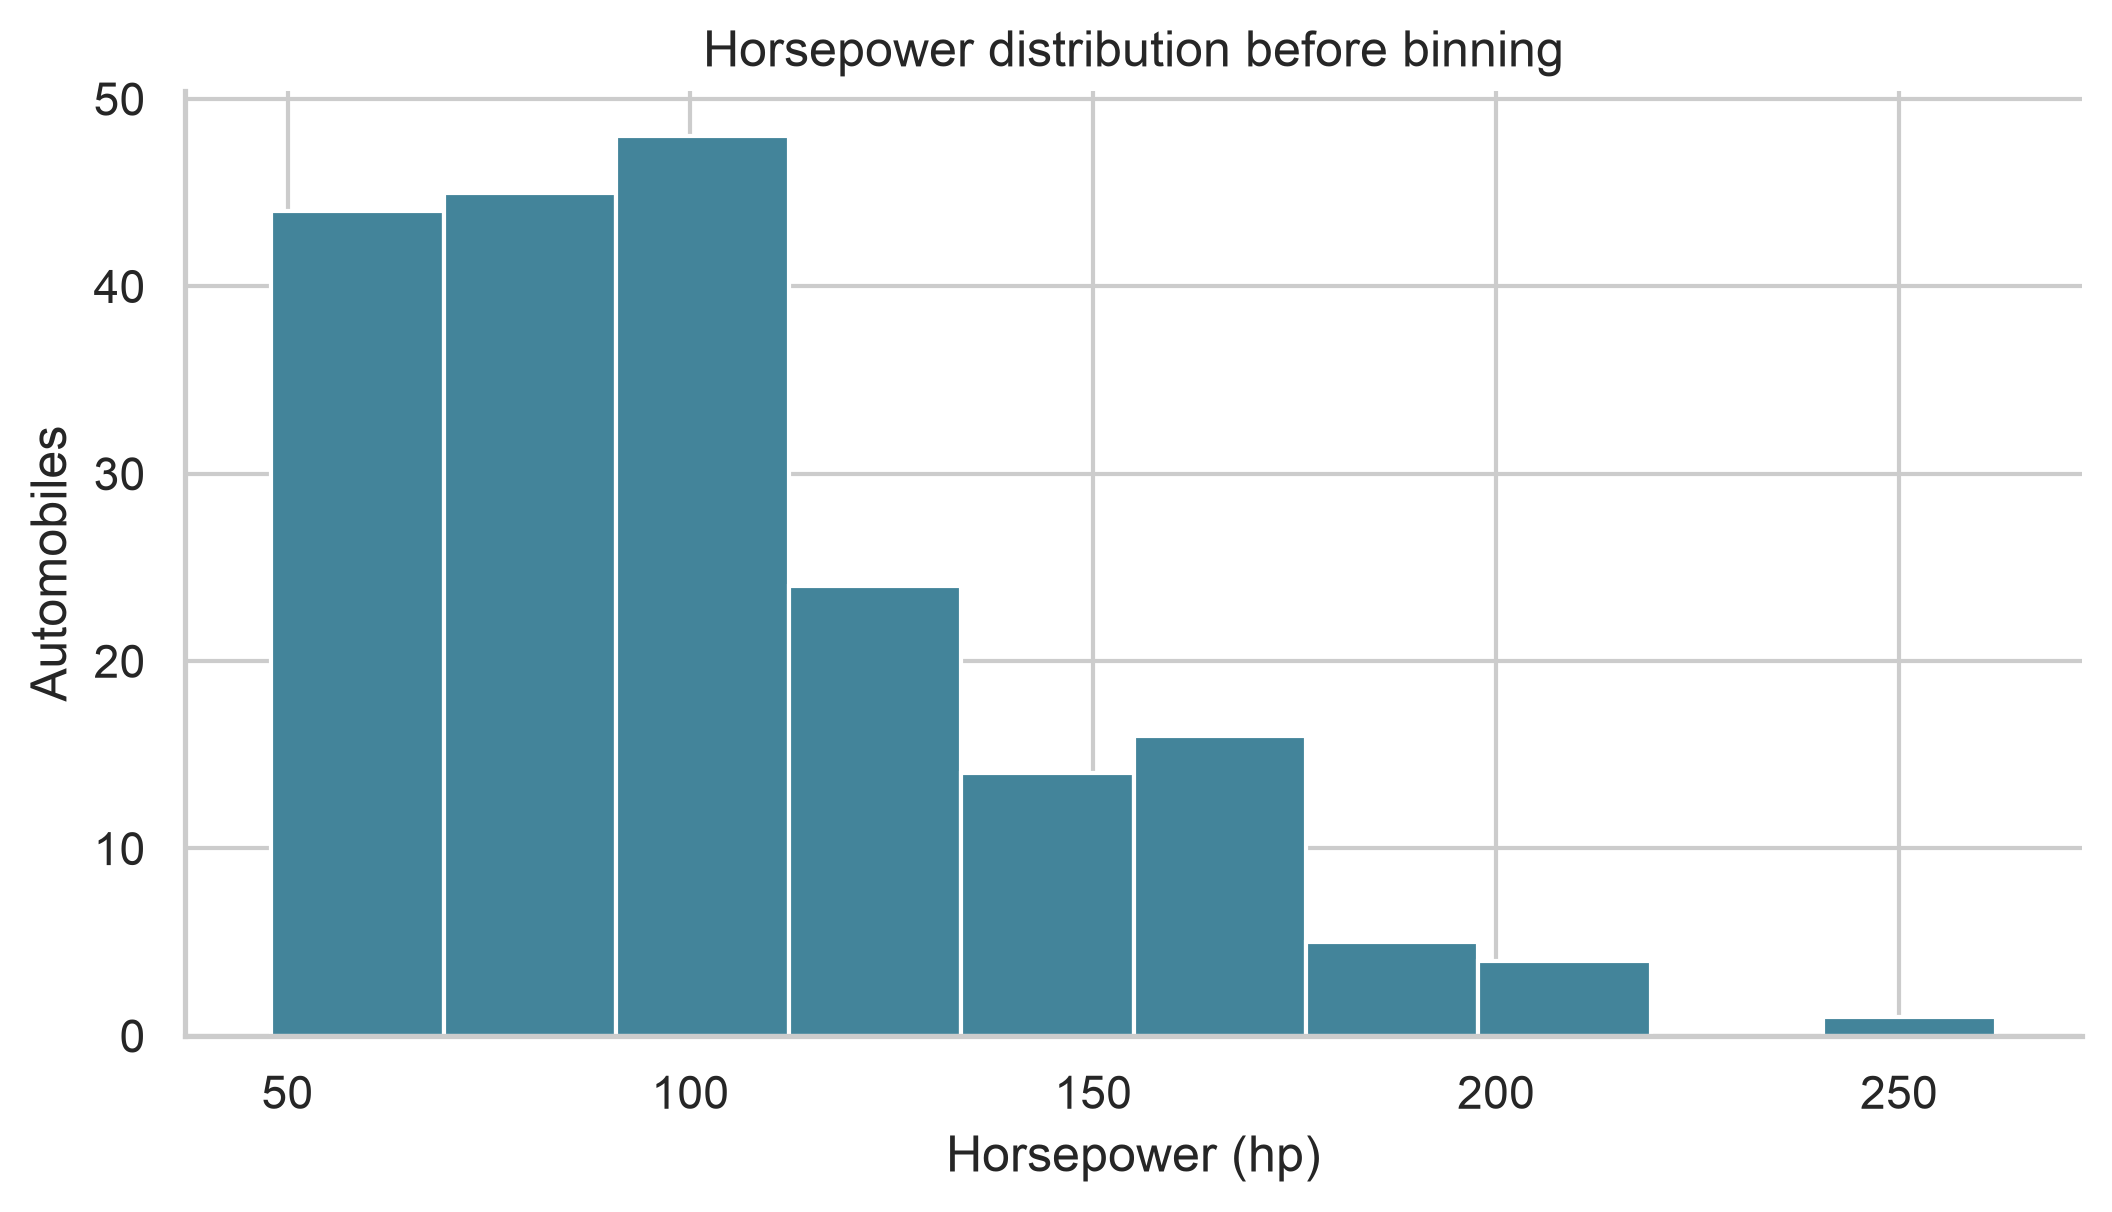

In [32]:
fig, ax = plt.subplots()
ax.hist(df['horsepower'], bins=10, color='#43849a', edgecolor='white')
ax.set(title='Horsepower distribution before binning', xlabel='Horsepower (hp)', ylabel='Automobiles')
fig.tight_layout()
plt.show()

<p>Find 3 bins of equal size bandwidth by using Numpy's <code>linspace(start_value, end_value, numbers_generated</code> function.</p>
<p>Since you want to include the minimum value of horsepower, set start_value = min(df["horsepower"]).</p>
<p>Since you want to include the maximum value of horsepower, set end_value = max(df["horsepower"]).</p>
<p>Since you are building 3 bins of equal length, you need 4 dividers, so numbers_generated = 4.</p>

Build a bin array with a minimum value to a maximum value by using the bandwidth calculated above. The values will determine when one bin ends and another begins.

In [33]:
bins = np.linspace(min(df["horsepower"]), max(df["horsepower"]), 4)
bins

array([ 48.        , 119.33333333, 190.66666667, 262.        ])

Set group  names:

In [34]:
group_names = ['Low', 'Medium', 'High']

Apply the function "cut" to determine what each value of `df['horsepower']` belongs to.

In [35]:
df['horsepower-binned'] = pd.cut(df['horsepower'], bins, labels=group_names, include_lowest=True )
df[['horsepower','horsepower-binned']].head(20)

,horsepower,horsepower-binned
0,111,Low
1,111,Low
2,154,Medium
3,102,Low
4,115,Low
5,110,Low
6,110,Low
7,110,Low
8,140,Medium
9,101,Low


See the number of vehicles in each bin:

In [36]:
horsepower_counts = df['horsepower-binned'].value_counts().reindex(group_names)
display(horsepower_counts.rename('Automobiles').to_frame())

,Automobiles
horsepower-binned,
Low,153
Medium,43
High,5


Plot the distribution of each bin:

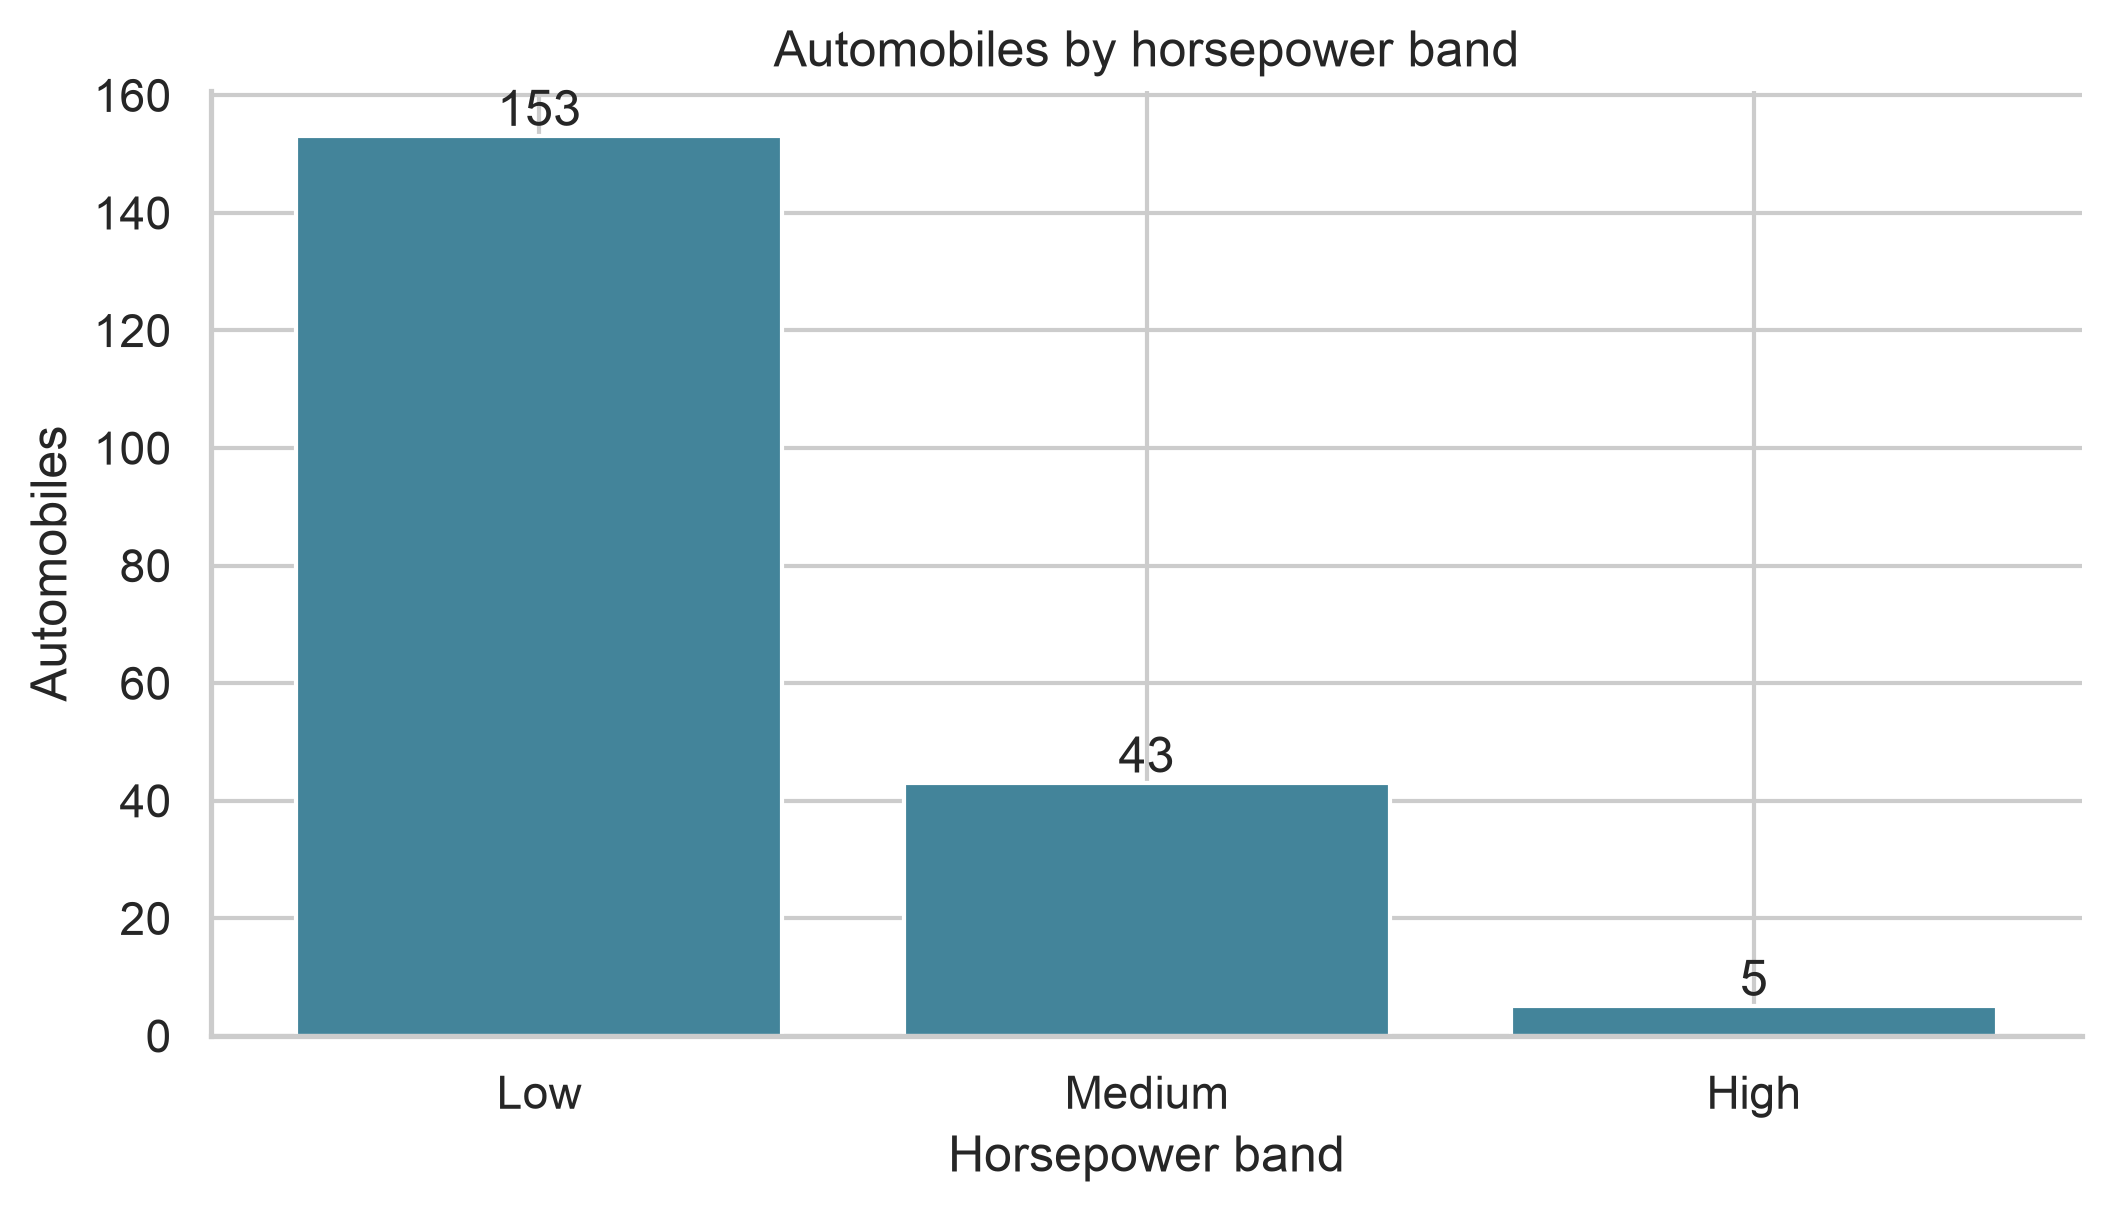

In [37]:
fig, ax = plt.subplots()
ax.bar(group_names, horsepower_counts, color='#43849a')
ax.set(title='Automobiles by horsepower band', xlabel='Horsepower band', ylabel='Automobiles')
ax.bar_label(ax.containers[0])
fig.tight_layout()
plt.show()

Equal-width intervals need not contain equal numbers of records. Counts are explicitly reindexed Low, Medium, High so the chart cannot accidentally attach a frequency to the wrong label.

<h3>Bins Visualization</h3>
Normally, you use a histogram to visualize the distribution of bins we created above.

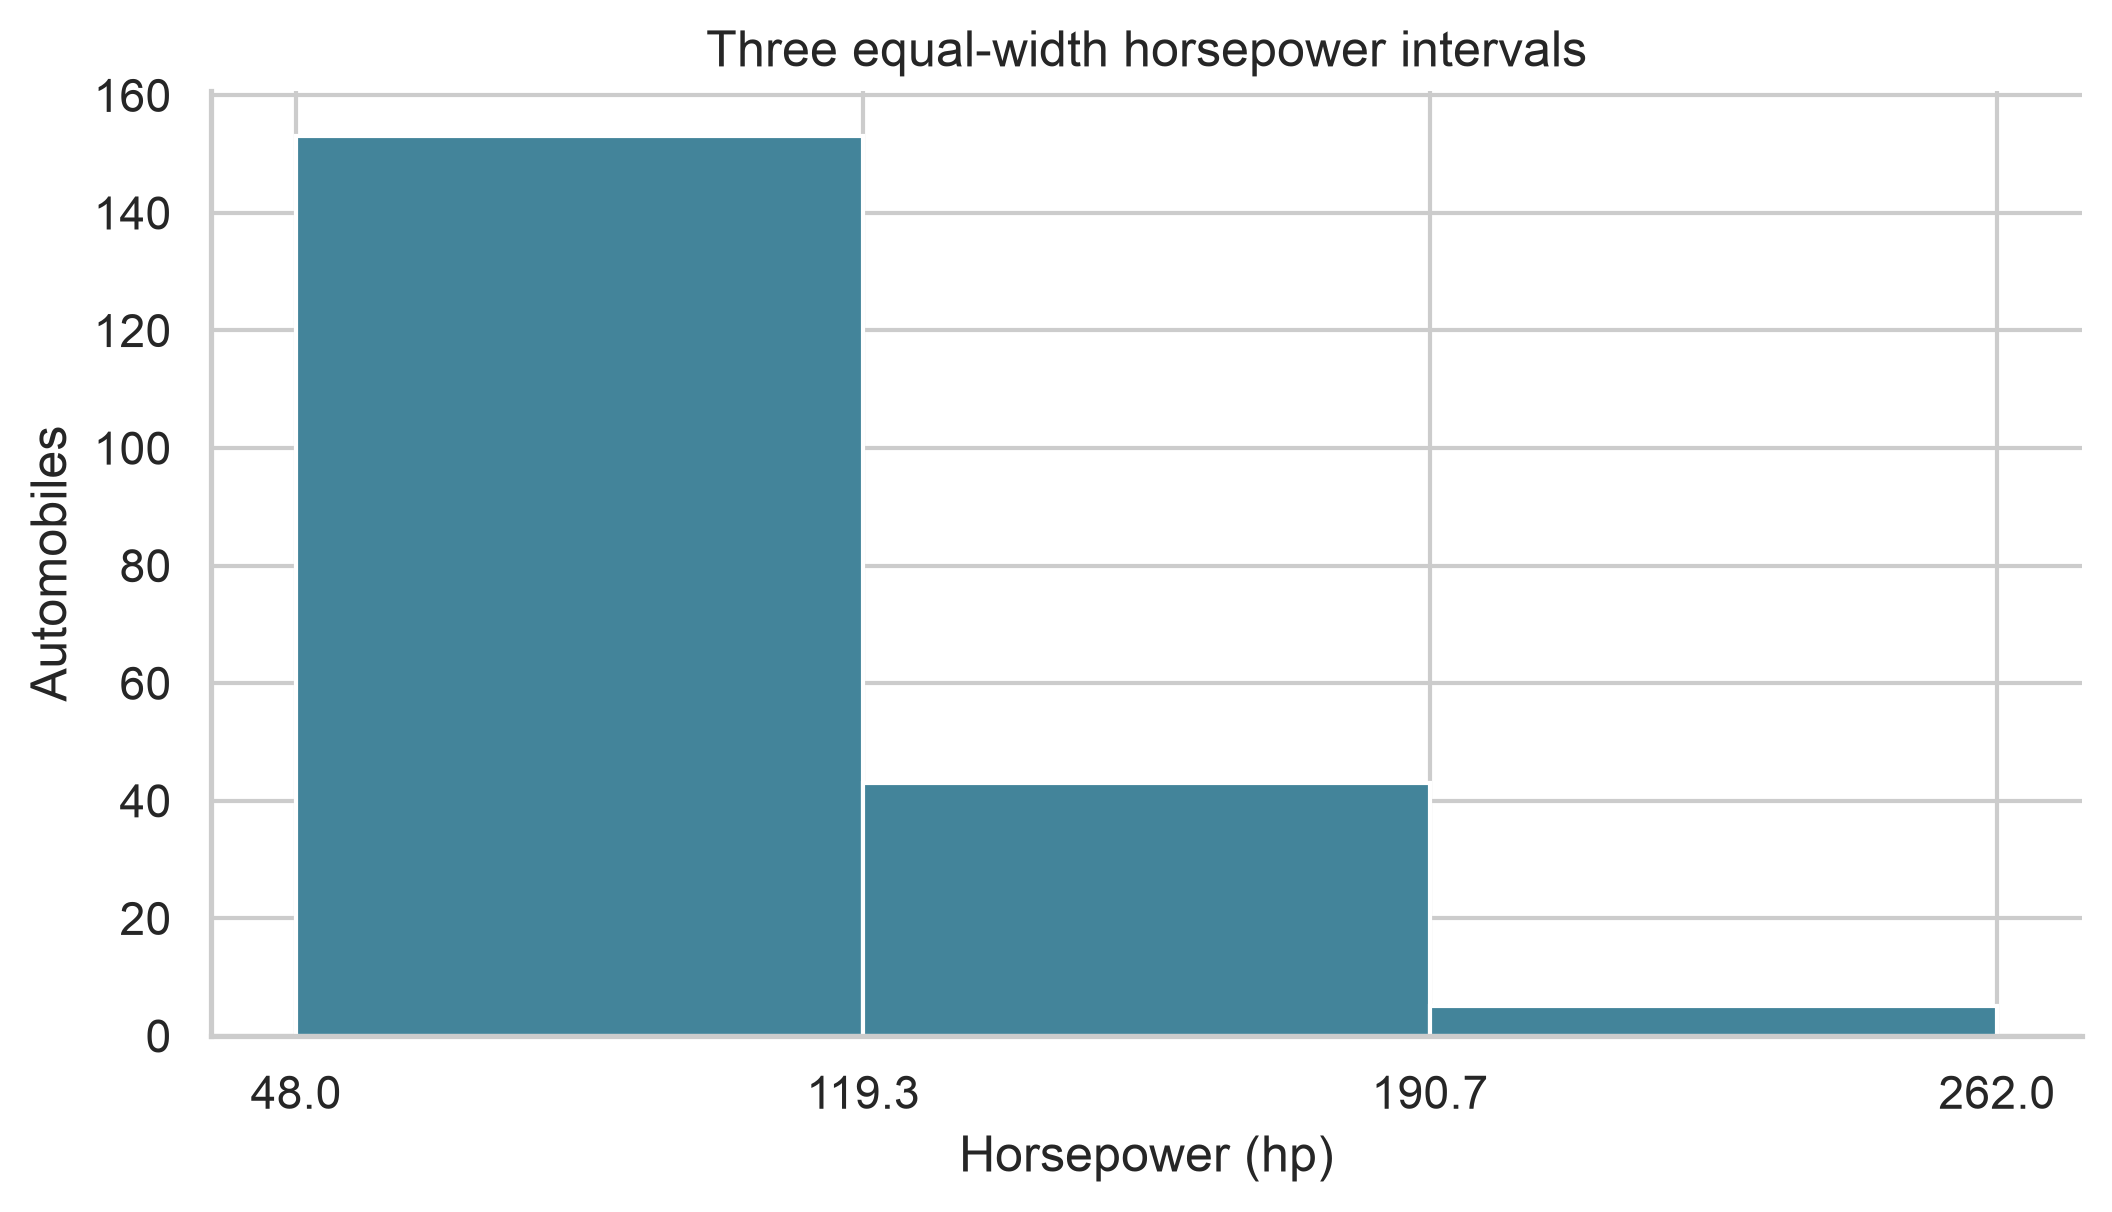

In [38]:
fig, ax = plt.subplots()
ax.hist(df['horsepower'], bins=bins, color='#43849a', edgecolor='white')
ax.set(title='Three equal-width horsepower intervals', xlabel='Horsepower (hp)', ylabel='Automobiles', xticks=bins)
fig.tight_layout()
plt.show()

The plot above shows the binning result for the attribute "horsepower".

## Indicator Variable

An indicator variable records category membership: 1 means that the observation belongs to the category, and 0 means that it does not. `get_dummies()` creates one such column for each observed category.

For example, `fuel-type` contains gas and diesel categories. Their indicator columns represent membership in these categories for subsequent regression analysis.

In [39]:
df.columns

Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
       'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
       'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
       'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-L/100km', 'price', 'city-L/100km', 'horsepower-binned'],
      dtype='str')

Get the indicator variables and assign it to data frame "dummy_variable_1":

In [40]:
dummy_variable_1 = pd.get_dummies(df['fuel-type'], dtype=int)
dummy_variable_1.head()

,diesel,gas
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1


Change the column names for clarity:

In [41]:
dummy_variable_1.rename(columns={'gas':'fuel-type-gas', 'diesel':'fuel-type-diesel'}, inplace=True)
dummy_variable_1.head()

,fuel-type-diesel,fuel-type-gas
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1


In the data frame, column 'fuel-type' now has values for 'gas' and 'diesel' as 0s and 1s.

In [42]:
# merge data frame "df" and "dummy_variable_1" 
df = pd.concat([df, dummy_variable_1], axis=1)

# drop original column "fuel-type" from "df"
df.drop("fuel-type", axis = 1, inplace=True)

In [43]:
df.head()

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-L/100km,price,city-L/100km,horsepower-binned,fuel-type-diesel,fuel-type-gas
0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.8111,0.8903,0.8161,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000.0,21,8.7037,13495.0,11.1905,Low,0,1
1,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.8111,0.8903,0.8161,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000.0,21,8.7037,16500.0,11.1905,Low,0,1
2,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,0.8227,0.9097,0.8763,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000.0,19,9.0385,16500.0,12.3684,Medium,0,1
3,2,164,audi,std,four,sedan,fwd,front,99.8,0.8486,0.9194,0.9080,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500.0,24,7.8333,13950.0,9.7917,Low,0,1
4,2,164,audi,std,four,sedan,4wd,front,99.4,0.8486,0.9222,0.9080,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500.0,18,10.6818,17450.0,13.0556,Low,0,1


The last two columns are now the indicator variable representation of the fuel-type variable. They're all 0s and 1s now.

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Question  #4: </h1>

<b>Similar to before, create an indicator variable for the column "aspiration"</b>
</div>

In [44]:
dummy_variable_2 = pd.get_dummies(df['aspiration'], dtype=int)
dummy_variable_2 = dummy_variable_2.rename(columns={'std': 'aspiration-std', 'turbo': 'aspiration-turbo'})
dummy_variable_2.head()

,aspiration-std,aspiration-turbo
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Question  #5: </h1>

<b>Merge the new dataframe to the original dataframe, then drop the column 'aspiration'.</b>
</div>

In [45]:
df = pd.concat([df, dummy_variable_2], axis=1).drop(columns='aspiration')
assert df[['aspiration-std', 'aspiration-turbo']].sum(axis=1).eq(1).all()
df[['aspiration-std', 'aspiration-turbo']].head()

,aspiration-std,aspiration-turbo
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0


The two indicators for a binary attribute add to one. Both are retained because the exercise requests them; a future regression with an intercept should avoid redundant columns or use suitable regularization.

Save the new csv:

In [46]:
output_path = OUTPUT_ROOT / 'datasets/processed/M02/clean_df.csv'
output_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(output_path, index=False)
assert len(df) == original_rows - missing_before['price']
assert not df.isna().any().any()
print(f'Saved {len(df)} rows × {df.shape[1]} columns to {output_path.name}; index excluded.')
display(df.head())

Saved 201 rows × 30 columns to clean_df.csv; index excluded.


,symboling,normalized-losses,make,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-L/100km,price,city-L/100km,horsepower-binned,fuel-type-diesel,fuel-type-gas,aspiration-std,aspiration-turbo
0,3,122,alfa-romero,two,convertible,rwd,front,88.6,0.8111,0.8903,0.8161,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000.0,21,8.7037,13495.0,11.1905,Low,0,1,1,0
1,3,122,alfa-romero,two,convertible,rwd,front,88.6,0.8111,0.8903,0.8161,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000.0,21,8.7037,16500.0,11.1905,Low,0,1,1,0
2,1,122,alfa-romero,two,hatchback,rwd,front,94.5,0.8227,0.9097,0.8763,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000.0,19,9.0385,16500.0,12.3684,Medium,0,1,1,0
3,2,164,audi,four,sedan,fwd,front,99.8,0.8486,0.9194,0.9080,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500.0,24,7.8333,13950.0,9.7917,Low,0,1,1,0
4,2,164,audi,four,sedan,4wd,front,99.4,0.8486,0.9222,0.9080,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500.0,18,10.6818,17450.0,13.0556,Low,0,1,1,0


## Original teaching-material credits

**Author:** [Joseph Santarcangelo](https://www.linkedin.com/in/joseph-s-50398b136/).

**Other contributors:** Mahdi Noorian, Bahare Talayian, Eric Xiao, Steven Dong, Parizad, Hima Vasudevan, Fiorella Wenver, Yi Yao, and Abhishek Gagneja.

© IBM Corporation 2023. All rights reserved.

## Tool acknowledgement

OpenAI Codex assisted with code completion, debugging and explanation drafting. Numerical results and figures were generated by executing the notebook in the recorded local Python environment. The collaborators are responsible for reviewing the analysis and submitted material. [OpenAI Codex](https://openai.com/codex/) (accessed 15 September 2026).